# **Sparse Coding sobre Digits Dataset (sklearn)**
# Diccionario Sobrecompleto con MiniBatchDictionaryLearning y SparseCoder



El dataset **Digits** de scikit-learn contiene 1 797 imágenes de dígitos escritos a
mano de 8×8 píxeles, con valores de intensidad en [0, 16]. Cada imagen es un vector
de **F = 64** características.

El objetivo es aprender un **diccionario sobrecompleto** D de shape **(K, F) = (256, 64)**
con K > F — más átomos que dimensiones — de forma que cualquier muestra pueda
representarse como combinación lineal dispersa de unos pocos átomos:


## **(1) Librerías y parámetros**

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_digits
from sklearn.decomposition import MiniBatchDictionaryLearning, SparseCoder
from sklearn.preprocessing import normalize

np.random.seed(42)

# ── Parámetros ─────────────────────────────────────────────────────────────
N_COMPONENTS = 256    # K: número de átomos  (> F=64  → diccionario sobrecompleto)
ALPHA        = 0.5    # penalización L1
BATCH_SIZE   = 200
MAX_ITER     = 100
THRESHOLD    = 1e-3   # umbral para considerar un coeficiente "activo"

print(f"F (dimensión de entrada) = 64")
print(f"K (átomos del diccionario) = {N_COMPONENTS}  →  ratio K/F = {N_COMPONENTS/64:.1f}×")
print(f"Diccionario sobrecompleto: {N_COMPONENTS} > 64  ✓")


F (dimensión de entrada) = 64
K (átomos del diccionario) = 256  →  ratio K/F = 4.0×
Diccionario sobrecompleto: 256 > 64  ✓


## **(2) Carga y exploración del dataset**

In [3]:
digits = load_digits()

X_raw = digits.data.astype(np.float64)   # (1797, 64)
y     = digits.target                     # etiquetas 0-9

print(f"Muestras : {X_raw.shape[0]}")
print(f"Features : {X_raw.shape[1]}  (imágenes 8×8 aplanadas)")
print(f"Clases   : {np.unique(y)}")
print(f"Rango    : [{X_raw.min():.0f}, {X_raw.max():.0f}]")

# Normalizar cada muestra a norma unitaria (estándar en sparse coding de parches)
X = normalize(X_raw, norm='l2')
print(f"\nTras normalización L2 — normas: min={np.linalg.norm(X, axis=1).min():.4f}  "
      f"max={np.linalg.norm(X, axis=1).max():.4f}")


Muestras : 1797
Features : 64  (imágenes 8×8 aplanadas)
Clases   : [0 1 2 3 4 5 6 7 8 9]
Rango    : [0, 16]

Tras normalización L2 — normas: min=1.0000  max=1.0000


## **(3) Visualización de muestras del dataset**

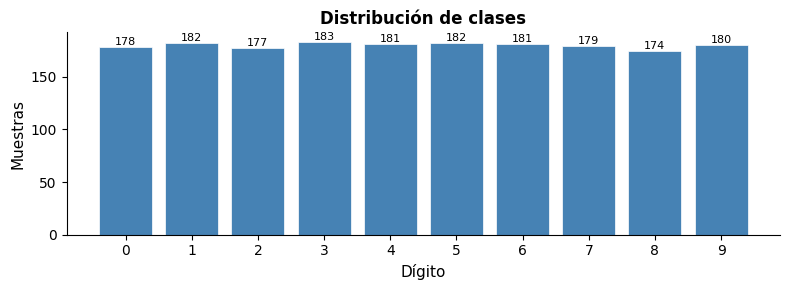

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle("Muestras del Dataset Digits (3 por clase)", fontsize=13, fontweight='bold')

for digit in range(10):
    idxs = np.where(y == digit)[0][:3]
    for row, idx in enumerate(idxs):
        ax = axes[row, digit]
        ax.imshow(digits.images[idx], cmap='gray_r', interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Distribución de clases
fig, ax = plt.subplots(figsize=(8, 3))
counts = np.bincount(y)
ax.bar(range(10), counts, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel("Dígito", fontsize=11)
ax.set_ylabel("Muestras", fontsize=11)
ax.set_title("Distribución de clases", fontsize=12, fontweight='bold')
ax.set_xticks(range(10))
for i, c in enumerate(counts):
    ax.text(i, c + 2, str(c), ha='center', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## **(4) Aprendizaje del diccionario sobrecompleto**

`MiniBatchDictionaryLearning` aprende D iterando en mini-lotes:
1. **Paso E** (encoding): fija D, encuentra A dispersa via LASSO/OMP
2. **Paso M** (update): fija A, actualiza D con gradiente estocástico

El diccionario resultante tiene shape **(256, 64)**: 256 átomos, cada uno con
64 valores — uno por píxel de la imagen 8×8.


In [ ]:
dico = MiniBatchDictionaryLearning(
    n_components=N_COMPONENTS,
    alpha=ALPHA,
    batch_size=BATCH_SIZE,
    max_iter=MAX_ITER,
    transform_algorithm='lasso_lars',
    fit_algorithm='cd',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print(f"Entrenando diccionario sobre {X.shape[0]} muestras...")
dico.fit(X)

D = dico.components_   # (N_COMPONENTS, 64)
print(f"\nDiccionario D: {D.shape}")
print(f"Ratio K/F     : {D.shape[0]}/{D.shape[1]} = {D.shape[0]/D.shape[1]:.1f}×  (sobrecompleto)")


Entrenando diccionario sobre 1797 muestras...

Diccionario D: (256, 64)
Ratio K/F     : 256/64 = 4.0×  (sobrecompleto)


## **(5) Visualización del diccionario**

Cada átomo se muestra como una imagen 8×8. Los átomos aprendidos capturan
patrones locales recurrentes en los dígitos: bordes, curvas, trazos diagonales.


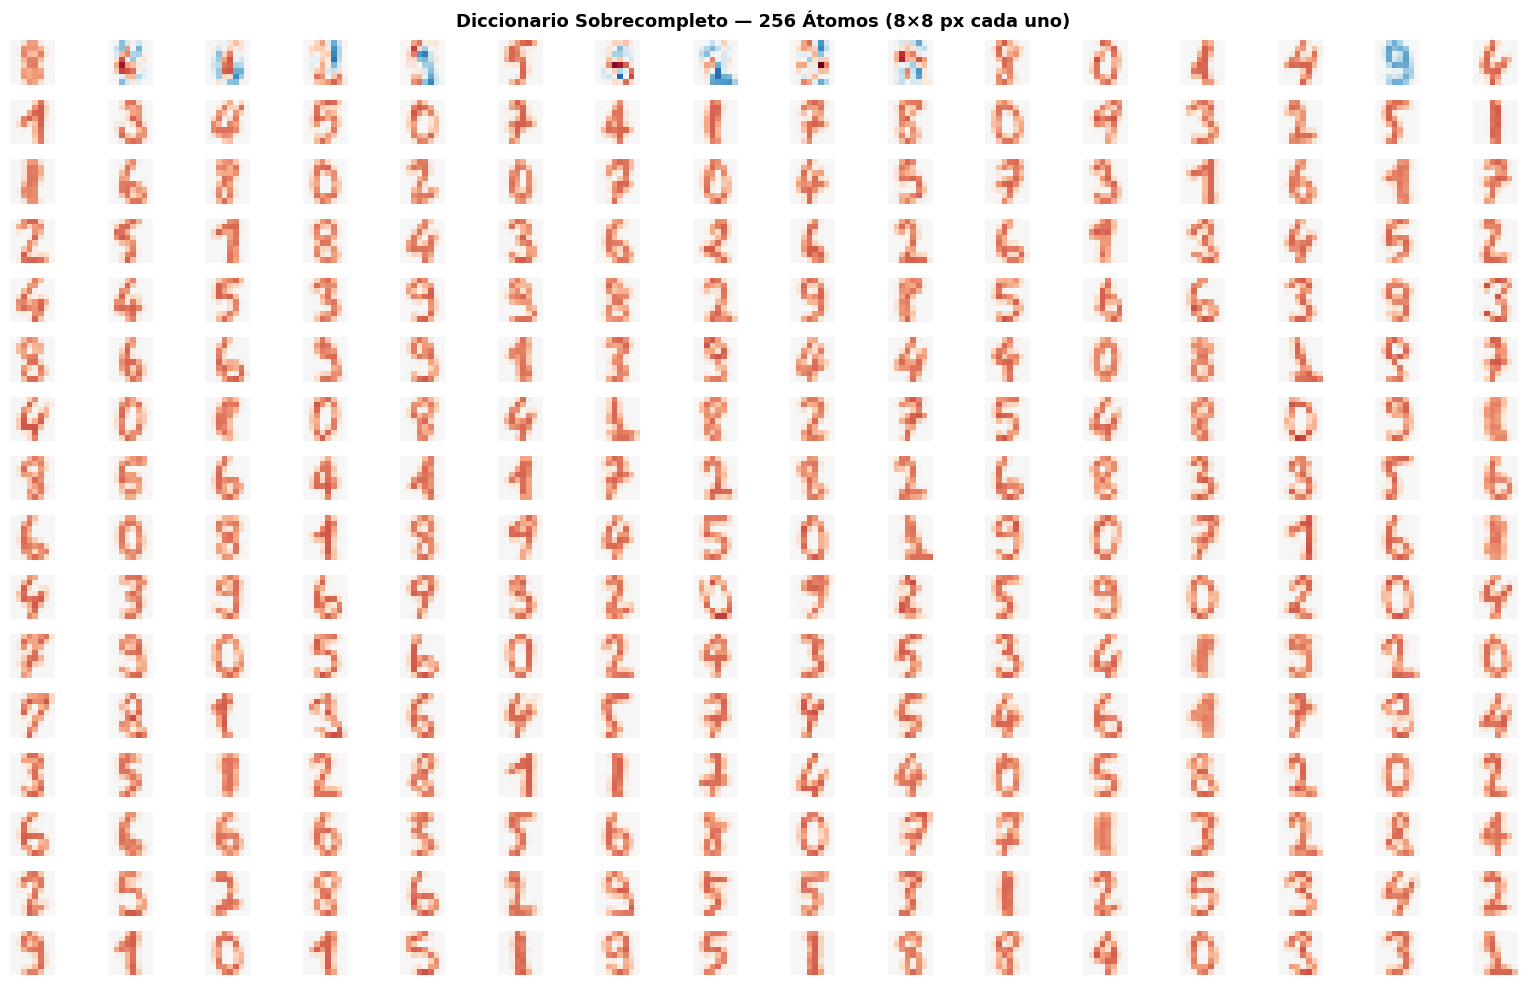

In [ ]:
n_cols = 16
n_rows = N_COMPONENTS // n_cols   # 16 filas × 16 cols = 256 átomos

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
fig.suptitle(f"Diccionario Sobrecompleto — {N_COMPONENTS} Átomos (8×8 px cada uno)",
             fontsize=13, fontweight='bold')

vmax = np.abs(D).max()

for i, ax in enumerate(axes.flat):
    atom = D[i].reshape(8, 8)
    ax.imshow(atom, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.axis('off')

plt.tight_layout()
plt.show()


## **(6) Codificación dispersa con SparseCoder**

Con el diccionario fijo, `SparseCoder` busca la representación A más dispersa
para cada muestra: `x ≈ A @ D` con ‖A‖₁ mínimo.

Se reporta:
- **Sparsity** = fracción de coeficientes nulos en A
- **Error de reconstrucción** relativo de Frobenius


In [ ]:
coder = SparseCoder(
    dictionary=D,
    transform_algorithm='lasso_lars',
    transform_alpha=ALPHA
)

A = coder.transform(X)   # (1797, 256)
X_rec = A @ D            # (1797, 64)

# ── Métricas globales ──────────────────────────────────────────────────────
error_rel = np.linalg.norm(X - X_rec) / (np.linalg.norm(X) + 1e-8)
nnz       = np.sum(np.abs(A) > THRESHOLD)
sparsity  = 1 - nnz / A.size
atoms_used = np.sum(np.any(np.abs(A) > THRESHOLD, axis=0))
avg_active = np.mean(np.sum(np.abs(A) > THRESHOLD, axis=1))

print("=" * 50)
print(f"Error relativo  ‖X - AD‖_F / ‖X‖_F : {error_rel:.4f}  ({error_rel*100:.2f}%)")
print(f"Sparsity (frac. ceros en A)          : {sparsity:.4f}  ({sparsity*100:.2f}%)")
print(f"Átomos activos en ≥1 muestra         : {atoms_used} / {N_COMPONENTS}")
print(f"Media de átomos activos por muestra  : {avg_active:.2f}")
print("=" * 50)


Error relativo  ‖X - AD‖_F / ‖X‖_F : 0.5492  (54.92%)
Sparsity (frac. ceros en A)          : 0.9931  (99.31%)
Átomos activos en ≥1 muestra         : 248 / 256
Media de átomos activos por muestra  : 1.77


## **(7) Distribución de coeficientes y uso de átomos**

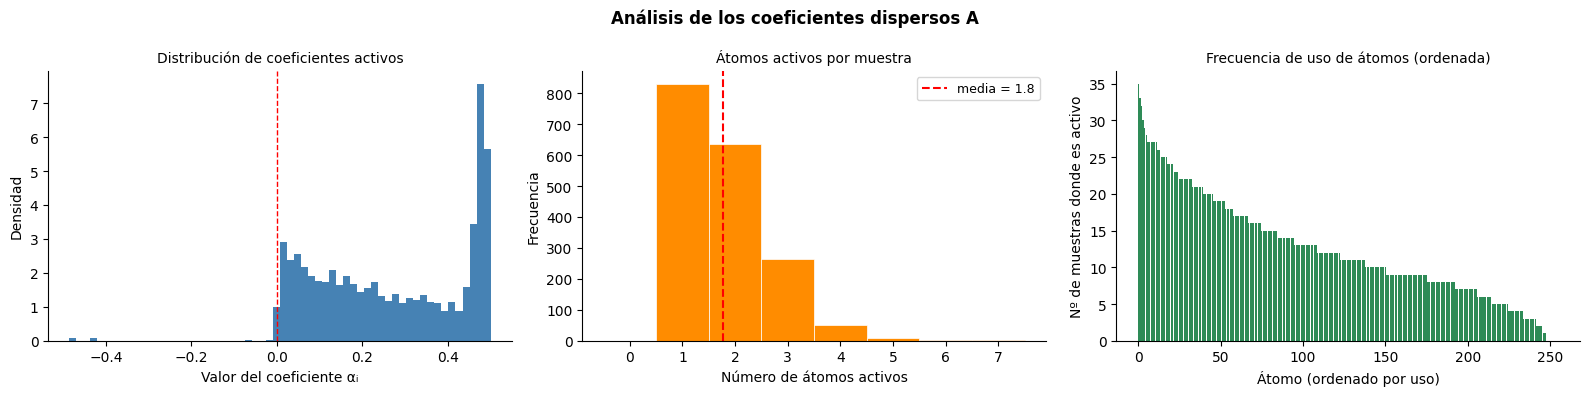

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Análisis de los coeficientes dispersos A", fontsize=12, fontweight='bold')

# (a) Histograma de todos los coeficientes no nulos
nonzero_vals = A[np.abs(A) > THRESHOLD].ravel()
axes[0].hist(nonzero_vals, bins=60, color='steelblue', edgecolor='none', density=True)
axes[0].set_title("Distribución de coeficientes activos", fontsize=10)
axes[0].set_xlabel("Valor del coeficiente αᵢ")
axes[0].set_ylabel("Densidad")
axes[0].axvline(0, color='red', lw=1, ls='--')
axes[0].spines[['top', 'right']].set_visible(False)

# (b) Número de átomos activos por muestra
active_per_sample = np.sum(np.abs(A) > THRESHOLD, axis=1)
axes[1].hist(active_per_sample, bins=range(0, active_per_sample.max() + 2),
             color='darkorange', edgecolor='white', linewidth=0.5, align='left')
axes[1].set_title("Átomos activos por muestra", fontsize=10)
axes[1].set_xlabel("Número de átomos activos")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(avg_active, color='red', lw=1.5, ls='--', label=f'media = {avg_active:.1f}')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

# (c) Frecuencia de uso de cada átomo (ordenada)
atom_freq = np.sum(np.abs(A) > THRESHOLD, axis=0)
sorted_freq = np.sort(atom_freq)[::-1]
axes[2].bar(range(N_COMPONENTS), sorted_freq, color='seagreen', linewidth=0)
axes[2].set_title("Frecuencia de uso de átomos (ordenada)", fontsize=10)
axes[2].set_xlabel("Átomo (ordenado por uso)")
axes[2].set_ylabel("Nº de muestras donde es activo")
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


## **(8) Átomos más y menos usados**

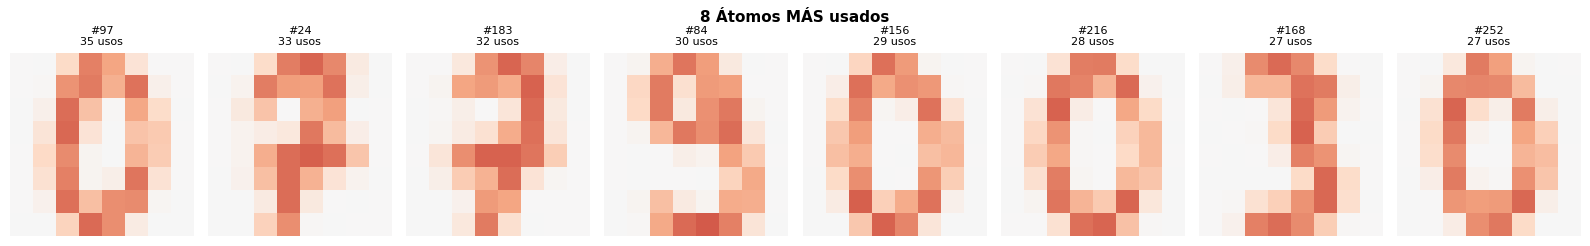

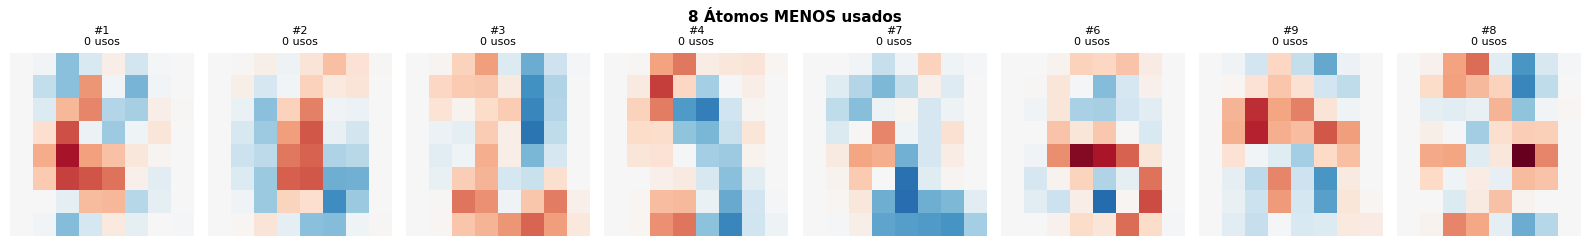

Top 8 átomos más usados:
  Rank 1: Átomo # 97 — activo en   35 muestras (1.9%)
  Rank 2: Átomo # 24 — activo en   33 muestras (1.8%)
  Rank 3: Átomo #183 — activo en   32 muestras (1.8%)
  Rank 4: Átomo # 84 — activo en   30 muestras (1.7%)
  Rank 5: Átomo #156 — activo en   29 muestras (1.6%)
  Rank 6: Átomo #216 — activo en   28 muestras (1.6%)
  Rank 7: Átomo #168 — activo en   27 muestras (1.5%)
  Rank 8: Átomo #252 — activo en   27 muestras (1.5%)


In [ ]:
atom_freq = np.sum(np.abs(A) > THRESHOLD, axis=0)
top8  = np.argsort(atom_freq)[::-1][:8]
bot8  = np.argsort(atom_freq)[:8]

def plot_atoms(indices, freq, title, cmap='RdBu_r'):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
    fig.suptitle(title, fontsize=11, fontweight='bold')
    vmax = np.abs(D).max()
    for ax, k in zip(axes, indices):
        ax.imshow(D[k].reshape(8, 8), cmap=cmap, vmin=-vmax, vmax=vmax,
                  interpolation='nearest')
        ax.set_title(f"#{k}\n{freq[k]} usos", fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_atoms(top8, atom_freq, "8 Átomos MÁS usados")
plot_atoms(bot8, atom_freq, "8 Átomos MENOS usados")

print("Top 8 átomos más usados:")
for r, k in enumerate(top8):
    print(f"  Rank {r+1}: Átomo #{k:3d} — activo en {atom_freq[k]:4d} muestras ({atom_freq[k]/X.shape[0]*100:.1f}%)")


## **(9) Reconstrucción — original vs reconstruido**

Se muestran 2 muestras por dígito junto con su reconstrucción `x̂ = A·D` y el
error relativo por muestra.


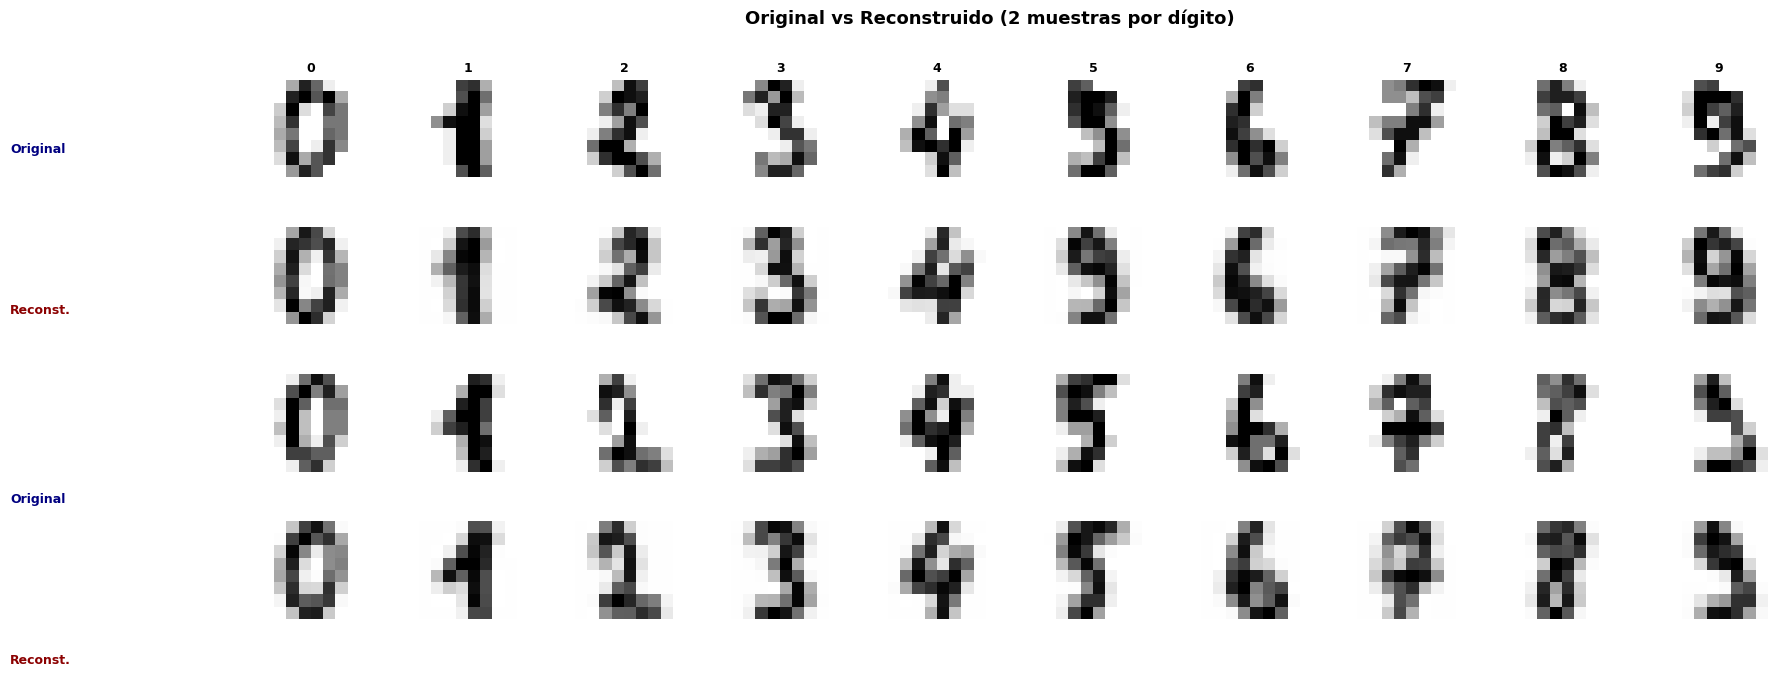

Error medio por muestra: 54.87%  ±  2.38%
Error máximo           : 68.92%
Error mínimo           : 50.00%


In [ ]:
# Error relativo por muestra
err_per = np.linalg.norm(X - X_rec, axis=1) / (np.linalg.norm(X, axis=1) + 1e-8)

fig = plt.figure(figsize=(20, 7))
fig.suptitle("Original vs Reconstruido (2 muestras por dígito)", fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(4, 10, hspace=0.5, wspace=0.1)

for digit in range(10):
    idxs = np.where(y == digit)[0][:2]
    for row_pair, idx in enumerate(idxs):
        # fila 0,1 → originales; fila 2,3 → reconstruidos
        ax_orig = fig.add_subplot(gs[row_pair * 2, digit])
        ax_rec  = fig.add_subplot(gs[row_pair * 2 + 1, digit])

        img_orig = X_raw[idx].reshape(8, 8)
        img_rec  = (X_rec[idx] * np.linalg.norm(X_raw[idx])).reshape(8, 8)

        ax_orig.imshow(img_orig, cmap='gray_r', interpolation='nearest')
        ax_orig.axis('off')
        if row_pair == 0:
            ax_orig.set_title(str(digit), fontsize=9, fontweight='bold')

        ax_rec.imshow(img_rec, cmap='gray_r', interpolation='nearest')
        ax_rec.axis('off')
        ax_rec.set_xlabel(f"{err_per[idx]*100:.0f}%", fontsize=7)

# Leyenda manual
fig.text(0.01, 0.78, "Original", va='center', fontsize=9, color='navy', fontweight='bold')
fig.text(0.01, 0.55, "Reconst.", va='center', fontsize=9, color='darkred', fontweight='bold')
fig.text(0.01, 0.28, "Original", va='center', fontsize=9, color='navy', fontweight='bold')
fig.text(0.01, 0.05, "Reconst.", va='center', fontsize=9, color='darkred', fontweight='bold')

plt.show()

print(f"Error medio por muestra: {err_per.mean()*100:.2f}%  ±  {err_per.std()*100:.2f}%")
print(f"Error máximo           : {err_per.max()*100:.2f}%")
print(f"Error mínimo           : {err_per.min()*100:.2f}%")


## **(10) Error de reconstrucción por dígito**

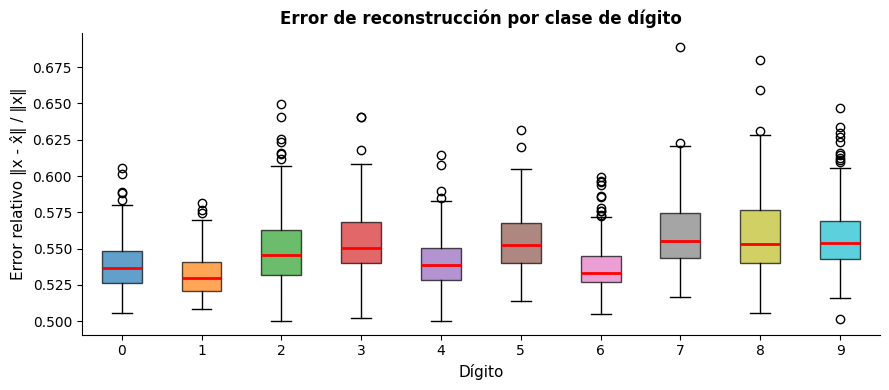

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

err_by_digit = [err_per[y == d] for d in range(10)]
bp = ax.boxplot(err_by_digit, patch_artist=True, medianprops=dict(color='red', lw=2))

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel("Dígito", fontsize=11)
ax.set_ylabel("Error relativo ‖x - x̂‖ / ‖x‖", fontsize=11)
ax.set_title("Error de reconstrucción por clase de dígito", fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_xticklabels(range(10))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## **(11) Tradeoff Sparsity vs Error de Reconstrucción**

Se barre `alpha` ∈ [0.01, 5.0] para ver cómo varía el compromiso entre
dispersión y fidelidad de reconstrucción.


alpha= 0.01  error=0.1153  sparsity=0.9231  átomos/muestra=19.7
alpha= 0.05  error=0.1915  sparsity=0.9727  átomos/muestra=7.0
alpha= 0.10  error=0.2200  sparsity=0.9807  átomos/muestra=4.9
alpha= 0.20  error=0.2872  sparsity=0.9869  átomos/muestra=3.4
alpha= 0.50  error=0.5492  sparsity=0.9931  átomos/muestra=1.8
alpha= 1.00  error=1.0000  sparsity=1.0000  átomos/muestra=0.0
alpha= 2.00  error=1.0000  sparsity=1.0000  átomos/muestra=0.0
alpha= 5.00  error=1.0000  sparsity=1.0000  átomos/muestra=0.0


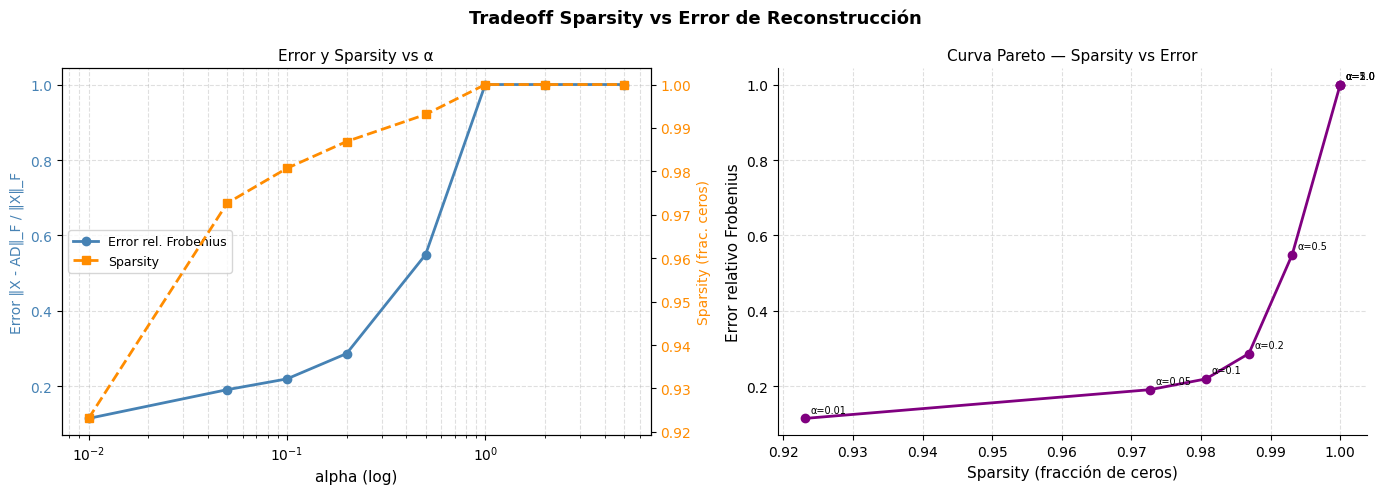

In [ ]:
ALPHAS = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

errors     = []
sparsities = []
avg_actives = []

for a in ALPHAS:
    c = SparseCoder(dictionary=D, transform_algorithm='lasso_lars', transform_alpha=a)
    Ai   = c.transform(X)
    Xhat = Ai @ D

    err = np.linalg.norm(X - Xhat) / (np.linalg.norm(X) + 1e-8)
    spa = 1 - np.mean(np.abs(Ai) > THRESHOLD)
    avg = np.mean(np.sum(np.abs(Ai) > THRESHOLD, axis=1))

    errors.append(err)
    sparsities.append(spa)
    avg_actives.append(avg)
    print(f"alpha={a:5.2f}  error={err:.4f}  sparsity={spa:.4f}  átomos/muestra={avg:.1f}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Tradeoff Sparsity vs Error de Reconstrucción", fontsize=13, fontweight='bold')

# Gráfica izquierda: error y sparsity vs alpha
color1, color2 = 'steelblue', 'darkorange'
ax1b = ax1.twinx()
ax1.semilogx(ALPHAS, errors, 'o-', color=color1, lw=2, label='Error rel. Frobenius')
ax1b.semilogx(ALPHAS, sparsities, 's--', color=color2, lw=2, label='Sparsity')
ax1.set_xlabel("alpha (log)", fontsize=11)
ax1.set_ylabel("Error ‖X - AD‖_F / ‖X‖_F", color=color1, fontsize=10)
ax1b.set_ylabel("Sparsity (frac. ceros)", color=color2, fontsize=10)
ax1.tick_params(axis='y', labelcolor=color1)
ax1b.tick_params(axis='y', labelcolor=color2)
lines = ax1.get_lines() + ax1b.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center left', fontsize=9)
ax1.grid(True, which='both', ls='--', alpha=0.4)
ax1.set_title("Error y Sparsity vs α", fontsize=11)

# Gráfica derecha: curva Pareto error vs sparsity
ax2.plot(sparsities, errors, 'o-', color='purple', lw=2)
for a, s, e in zip(ALPHAS, sparsities, errors):
    ax2.annotate(f"α={a}", (s, e), textcoords='offset points', xytext=(4, 4), fontsize=7)
ax2.set_xlabel("Sparsity (fracción de ceros)", fontsize=11)
ax2.set_ylabel("Error relativo Frobenius", fontsize=11)
ax2.set_title("Curva Pareto — Sparsity vs Error", fontsize=11)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()


## **(12) Visualización de la matriz de coeficientes A**

La matriz A de shape (N_muestras, K) muestra qué átomos activa cada muestra.
Se visualiza como heatmap ordenando las muestras por dígito.


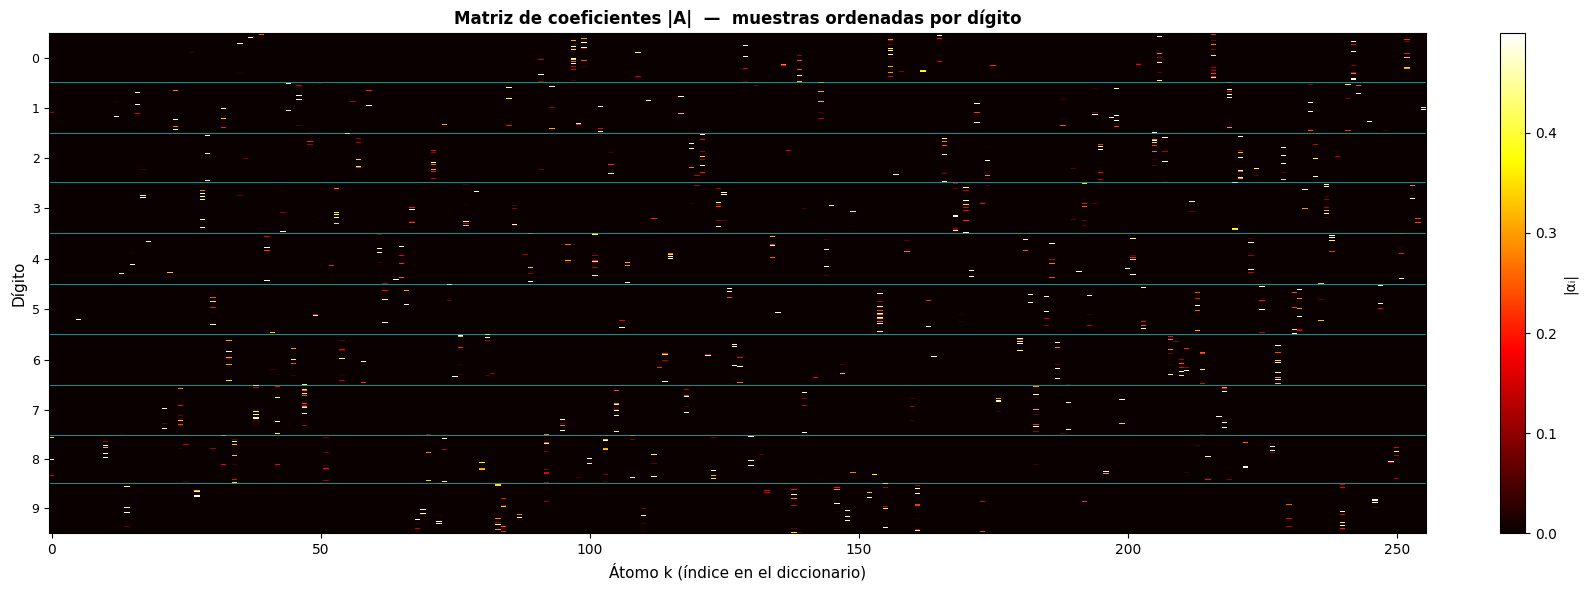

In [ ]:
# Ordenar muestras por dígito para ver patrones por clase
sort_idx = np.argsort(y)
A_sorted = A[sort_idx]
y_sorted = y[sort_idx]

fig, ax = plt.subplots(figsize=(16, 6))
img = ax.imshow(
    np.abs(A_sorted),
    aspect='auto',
    cmap='hot',
    interpolation='nearest'
)
plt.colorbar(img, ax=ax, label="|αᵢ|", fraction=0.02)

# Líneas divisorias entre dígitos
boundaries = np.where(np.diff(y_sorted))[0] + 1
for b in boundaries:
    ax.axhline(b - 0.5, color='cyan', lw=0.6, alpha=0.7)

# Etiquetas de dígitos en el eje Y
tick_pos   = [np.where(y_sorted == d)[0].mean() for d in range(10)]
ax.set_yticks(tick_pos)
ax.set_yticklabels([str(d) for d in range(10)], fontsize=9)
ax.set_xlabel("Átomo k (índice en el diccionario)", fontsize=11)
ax.set_ylabel("Dígito", fontsize=11)
ax.set_title("Matriz de coeficientes |A|  —  muestras ordenadas por dígito", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
